In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, ConcatDataset
import tifffile as tiff
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE
from PIL import Image
from tqdm import tqdm
from torchvision import transforms

from skimage import io
import sys
# from umap import UMAP
import joblib
from datetime import datetime

# Load Data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
# Get the directory of the script
script_dir = os.getcwd()

# Get the parent directory of the script
parent_dir = os.path.dirname(script_dir)

# Add the parent directory to sys.path
sys.path.append(parent_dir)

from core.autoencoders import AE, train_ae
from core.dataset import TIFFDataset
from utils.feature_analysis import UMAP_train, dataloader_model_latents,kmeans_cluster,DBSCAN_cluster
from utils.plotting_utils import umap_2Dplot, cluster_2Dplot



In [7]:
data_str = 'vin_pax_zyx_act_wholecell'
pro_str = 'pax_front_localmax_correctloader'
main_ch = 1
ctrl_y_str = 'ctrl_y'
input_ps = 16
latent_dim_array = [4,6,8,10,12,14,16,18,20,22,24]
latent_dim_array = [8,12,24]
BN_flag = True
dropout_flag = True
epochs = int(10000)
lr = 1e-4
eps = 3
min_samples = 5
kmeans_num_clusters = 6
loss_norm_flag = 0

dir_list = [
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/ctrl_ch1_major/ctrl_ch1_patches_localmax_rotation_pslocation00/tiff_patches16_65p_20251015_1131',
'/mnt/d/lding/FA/analysis_results/FA_ML_Annabel_20250217/031125/y_ch1_major/y_ch1_patches_localmax_norotation_pslocation00/tiff_patches16_65p_20251015_1143',    
]




In [8]:

transform = transforms.Compose([transforms.ToTensor()])

datasets = [
    TIFFDataset(root_dir=dir_path, label=label, transform=transform)
    for label, dir_path in enumerate(dir_list)
]

combined_dataset = ConcatDataset(datasets)

# Split dataset into training and validation sets
train_size = int(0.8 * len(combined_dataset))
val_size = len(combined_dataset) - train_size
train_dataset, val_dataset = random_split(combined_dataset, [train_size, val_size])
whole_data_loader = DataLoader(combined_dataset, batch_size=128, shuffle=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)



In [9]:
total_sum_sq = 0.0
total_sum = 0.0
n_total = 0

for images, _ in whole_data_loader:
    images = images.to(torch.float32)
    total_sum += (images).sum().item()
    total_sum_sq += (images ** 2).sum().item()
    n_total += images.numel()

mean_square = total_sum_sq / n_total
mean = total_sum / n_total
print("Mean square of all pixels:", mean_square)

joblib.dump(mean_square,'../results/pax_front_ps16_mean_square.pkl')

Mean square of all pixels: 0.03960830013296636


['../results/pax_front_ps16_mean_square.pkl']

Epoch 200/10000, Train Loss: 0.0049, Val Loss: 0.0051
Epoch 400/10000, Train Loss: 0.0045, Val Loss: 0.0052
Epoch 600/10000, Train Loss: 0.0043, Val Loss: 0.0054
Epoch 800/10000, Train Loss: 0.0041, Val Loss: 0.0055
Epoch 1000/10000, Train Loss: 0.0040, Val Loss: 0.0056
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0026, max: 0.9914, mean: 0.1272, std: 0.1335
Epoch 1200/10000, Train Loss: 0.0039, Val Loss: 0.0057
Epoch 1400/10000, Train Loss: 0.0038, Val Loss: 0.0058
Epoch 1600/10000, Train Loss: 0.0038, Val Loss: 0.0059
Epoch 1800/10000, Train Loss: 0.0037, Val Loss: 0.0059
Epoch 2000/10000, Train Loss: 0.0037, Val Loss: 0.0059
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0027, max: 0.9914, mean: 0.1247, std: 0.1328
Epoch 2200/10000, Train Loss: 0.0036, Val Loss: 0.0059
Epoch 2400/10000, Train Loss: 0.0036, Val Loss: 0.0060
Epoch 2600/10000, Train Loss: 0.0035, Val Loss: 0.0060
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.0040, Val Loss: 0.0041
Epoch 400/10000, Train Loss: 0.0037, Val Loss: 0.0042
Epoch 600/10000, Train Loss: 0.0035, Val Loss: 0.0043
Epoch 800/10000, Train Loss: 0.0033, Val Loss: 0.0044
Epoch 1000/10000, Train Loss: 0.0032, Val Loss: 0.0045
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0012, max: 0.9899, mean: 0.1230, std: 0.1363
Epoch 1200/10000, Train Loss: 0.0031, Val Loss: 0.0045
Epoch 1400/10000, Train Loss: 0.0031, Val Loss: 0.0046
Epoch 1600/10000, Train Loss: 0.0030, Val Loss: 0.0046
Epoch 1800/10000, Train Loss: 0.0030, Val Loss: 0.0047
Epoch 2000/10000, Train Loss: 0.0030, Val Loss: 0.0047
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0021, max: 0.9935, mean: 0.1231, std: 0.1360
Epoch 2200/10000, Train Loss: 0.0029, Val Loss: 0.0047
Epoch 2400/10000, Train Loss: 0.0029, Val Loss: 0.0047
Epoch 2600/10000, Train Loss: 0.0029, Val Loss: 0.0047
Epoch 2

/mnt/d/lding/CLS_GitHub/fa_patch_AE_clustering/core/autoencoders.py:97: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(2, n, figsize=(n * 1, 2))


Epoch 5200/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 5400/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 5600/10000, Train Loss: 0.0027, Val Loss: 0.0048
Epoch 5800/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 6000/10000, Train Loss: 0.0027, Val Loss: 0.0049
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0013, max: 0.9958, mean: 0.1241, std: 0.1339
Epoch 6200/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 6400/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 6600/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 6800/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 7000/10000, Train Loss: 0.0027, Val Loss: 0.0049
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0007, max: 0.9966, mean: 0.1206, std: 0.1342
Epoch 7200/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 7400/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epoch 7600/10000, Train Loss: 0.0027, Val Loss: 0.0049
Epo

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Epoch 200/10000, Train Loss: 0.0029, Val Loss: 0.0027
Epoch 400/10000, Train Loss: 0.0027, Val Loss: 0.0027
Epoch 600/10000, Train Loss: 0.0026, Val Loss: 0.0027
Epoch 800/10000, Train Loss: 0.0025, Val Loss: 0.0028
Epoch 1000/10000, Train Loss: 0.0024, Val Loss: 0.0028
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0027, max: 0.9834, mean: 0.1202, std: 0.1371
Epoch 1200/10000, Train Loss: 0.0024, Val Loss: 0.0029
Epoch 1400/10000, Train Loss: 0.0024, Val Loss: 0.0029
Epoch 1600/10000, Train Loss: 0.0023, Val Loss: 0.0029
Epoch 1800/10000, Train Loss: 0.0023, Val Loss: 0.0029
Epoch 2000/10000, Train Loss: 0.0023, Val Loss: 0.0029
Input stats — min: 0.0000, max: 0.9486, mean: 0.1242, std: 0.1507
Reconstruction stats — min: 0.0017, max: 0.9898, mean: 0.1201, std: 0.1375
Epoch 2200/10000, Train Loss: 0.0022, Val Loss: 0.0029
Epoch 2400/10000, Train Loss: 0.0022, Val Loss: 0.0029
Epoch 2600/10000, Train Loss: 0.0022, Val Loss: 0.0030
Epoch 2

/home/ldin/.local/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


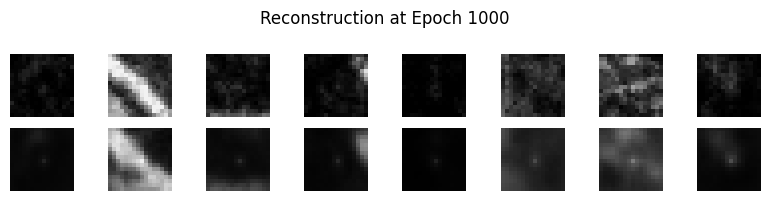

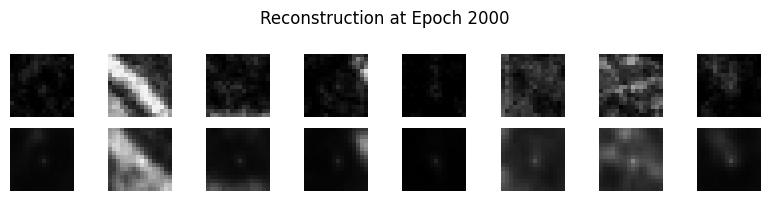

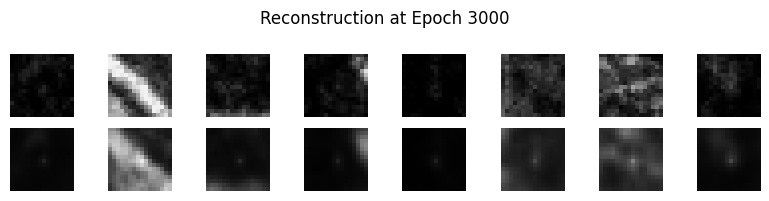

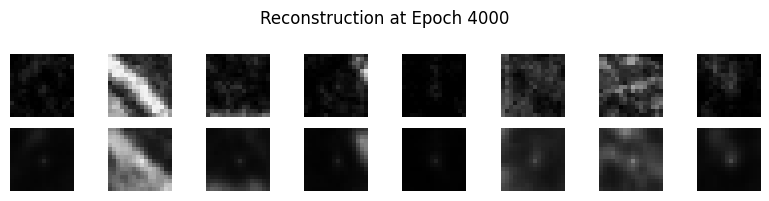

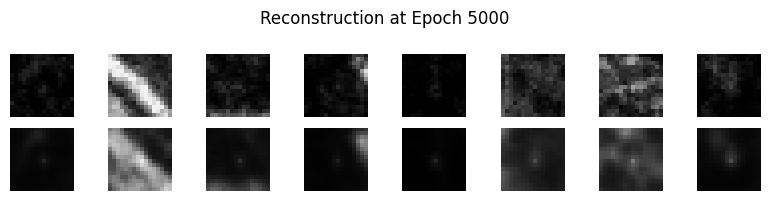

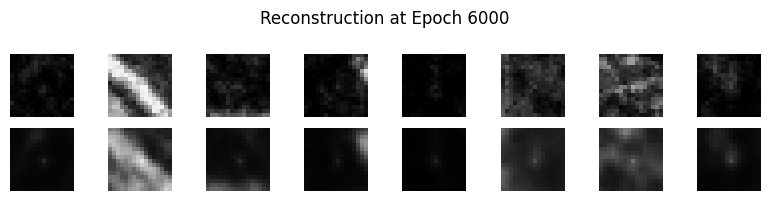

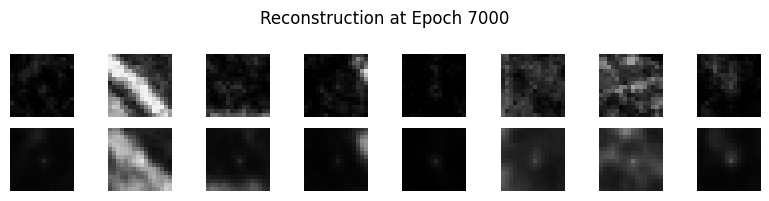

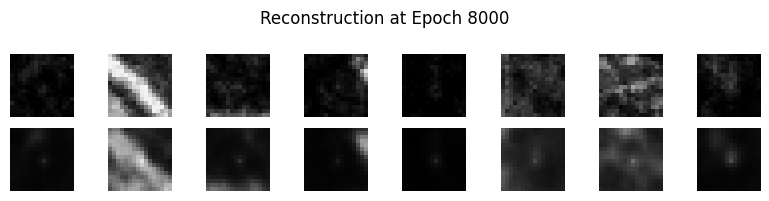

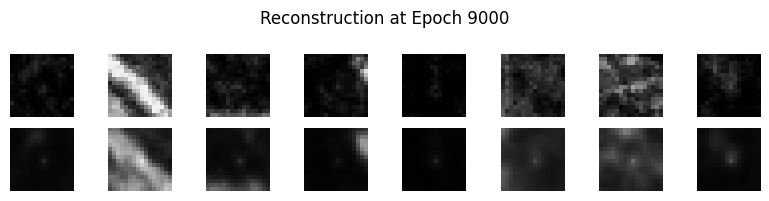

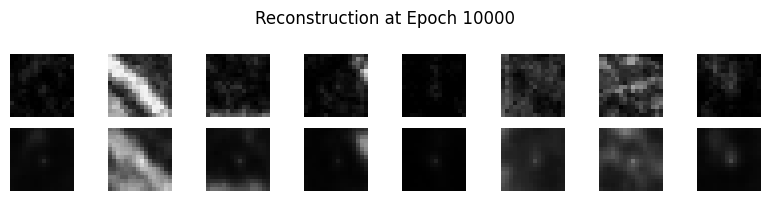

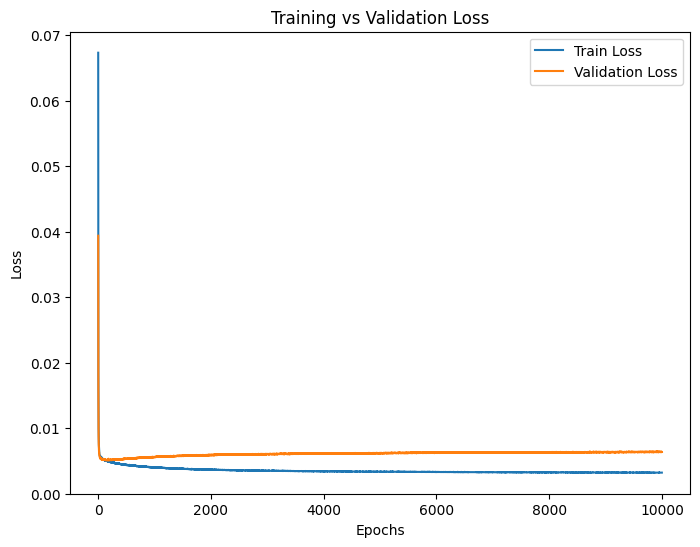

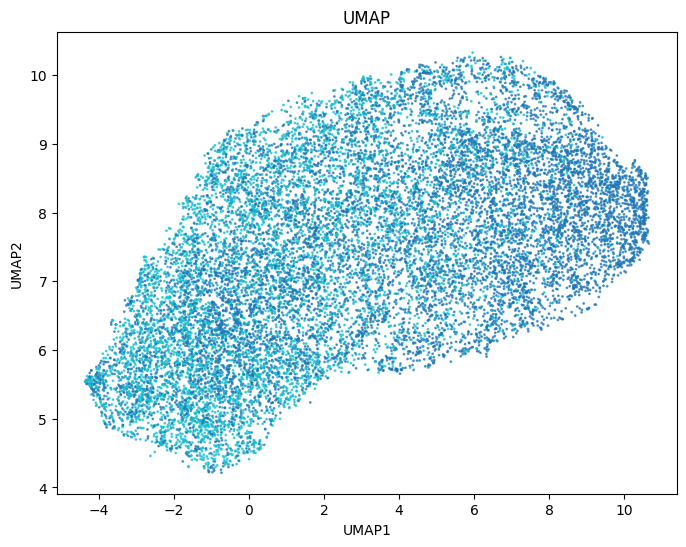

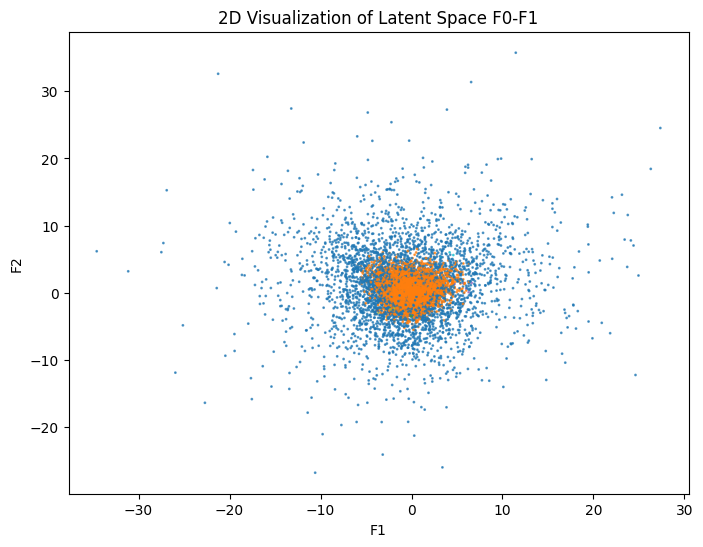

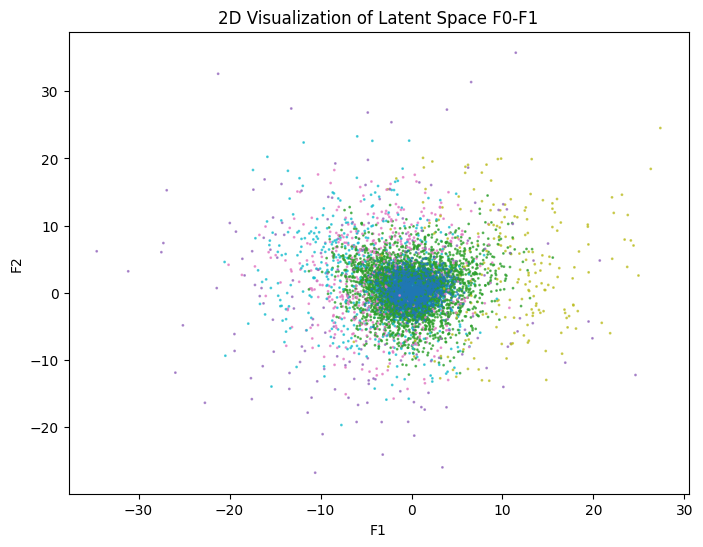

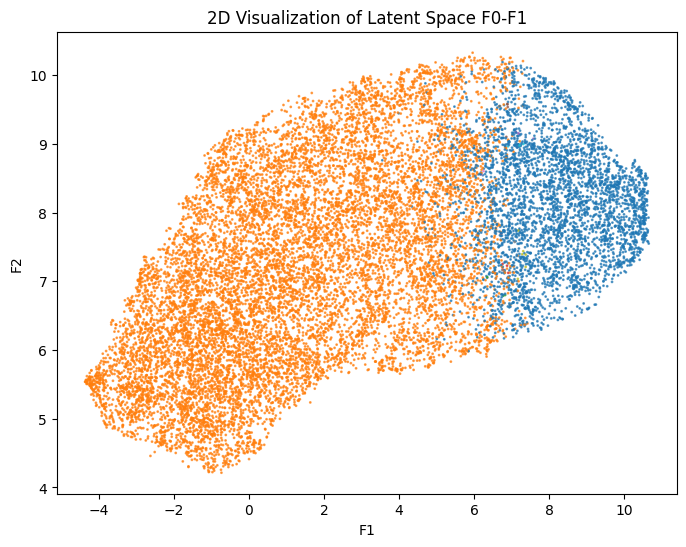

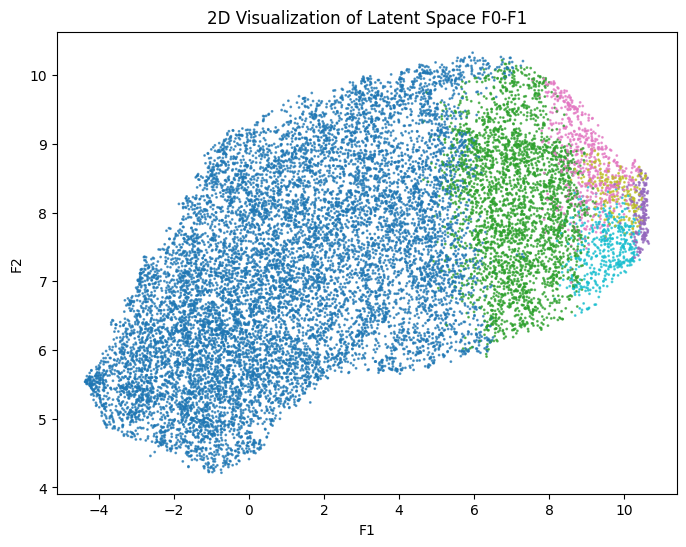

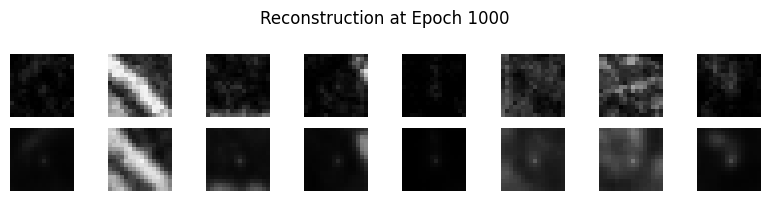

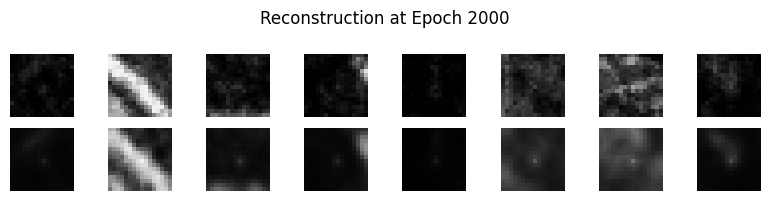

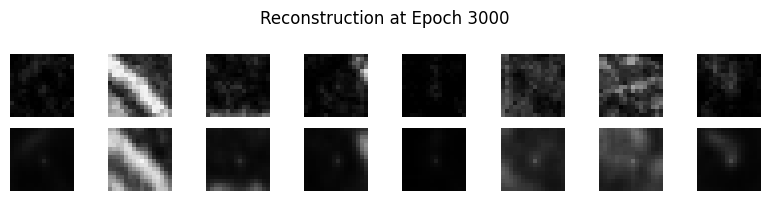

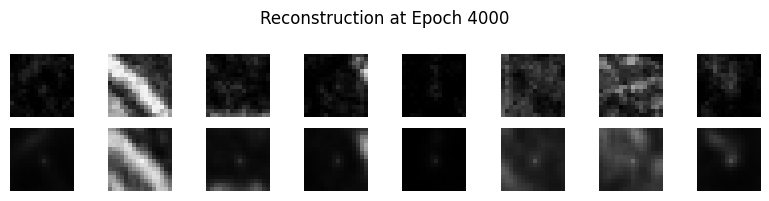

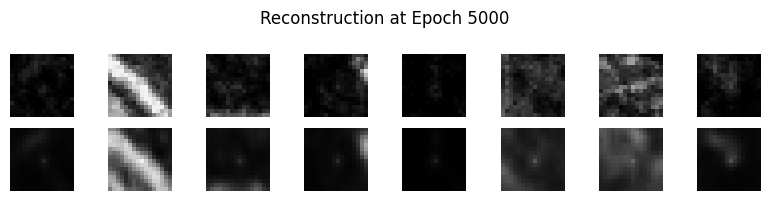

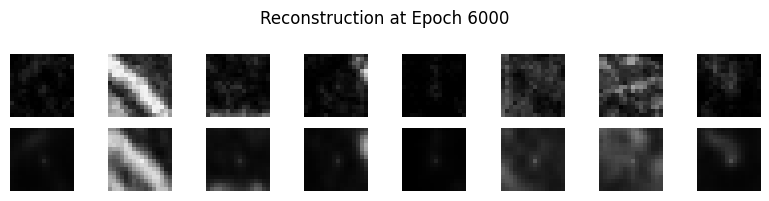

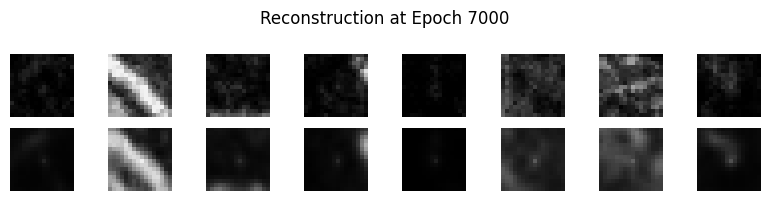

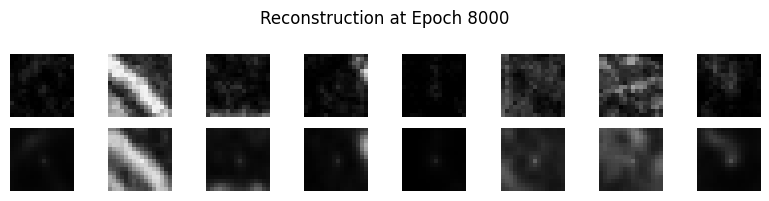

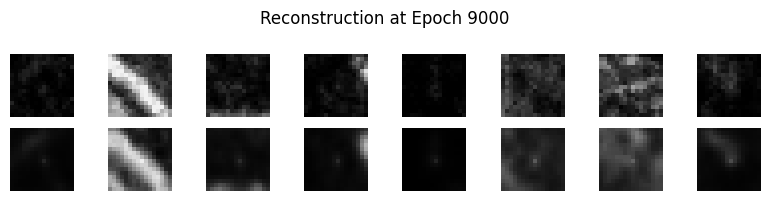

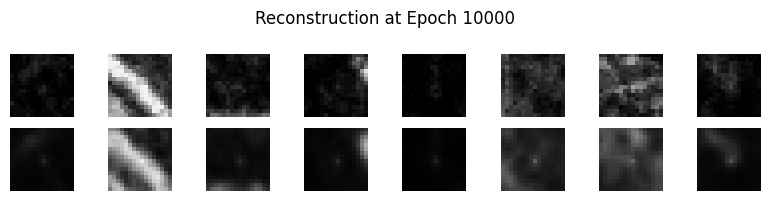

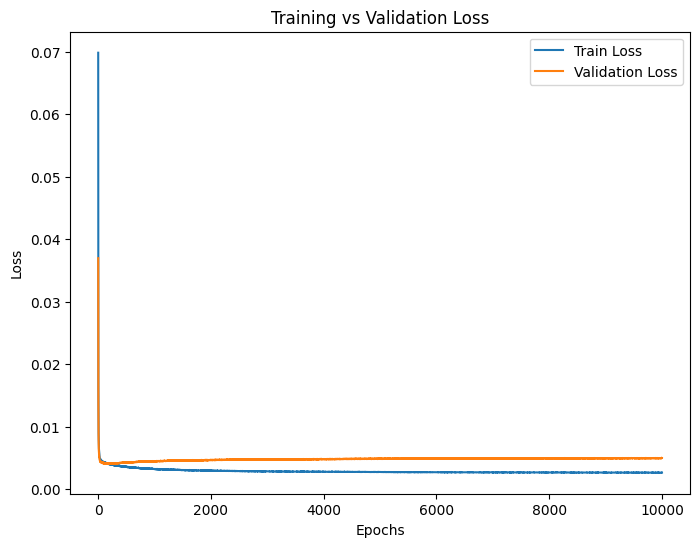

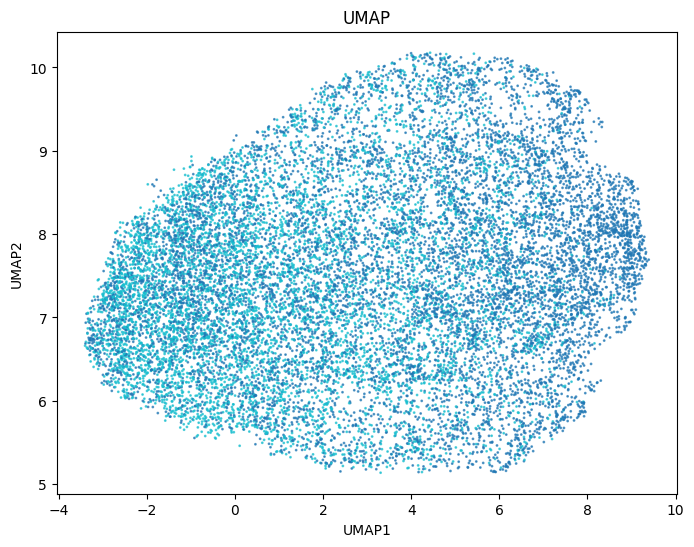

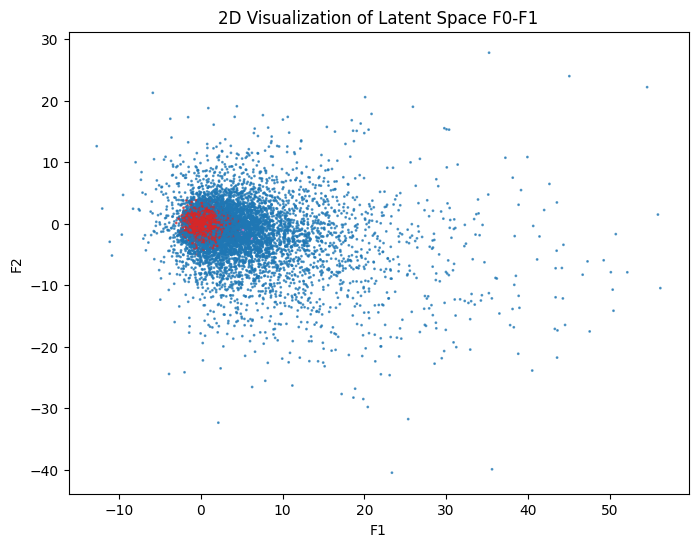

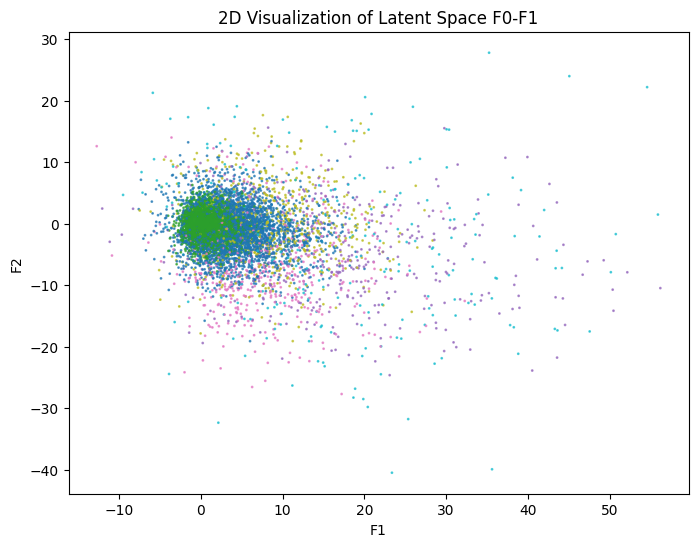

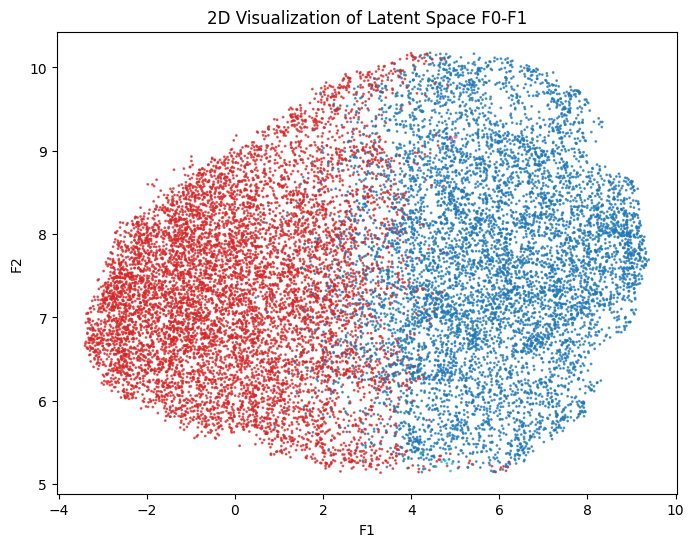

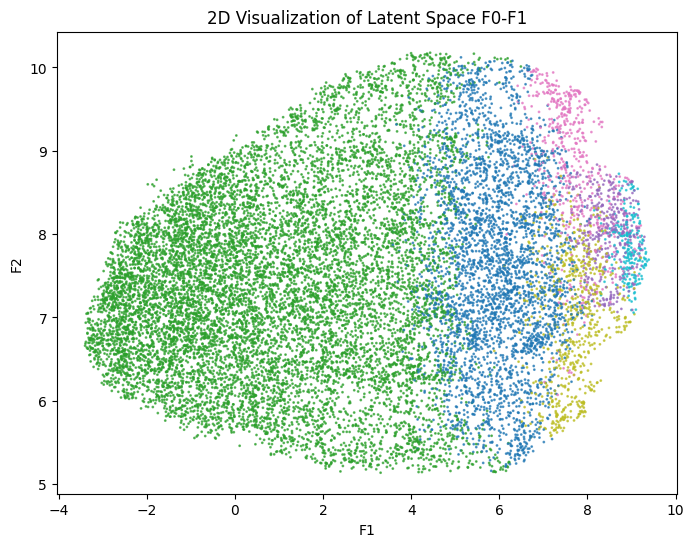

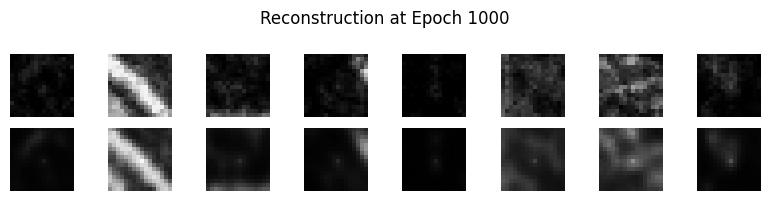

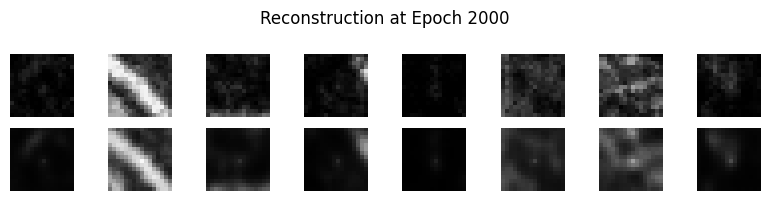

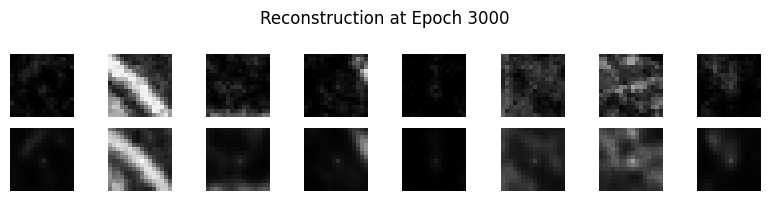

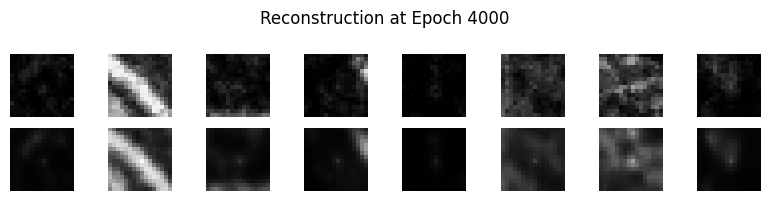

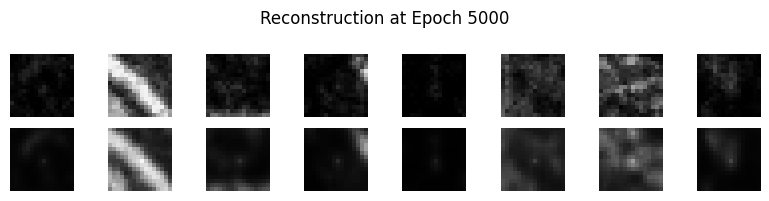

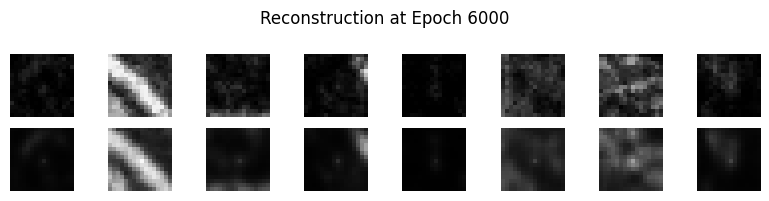

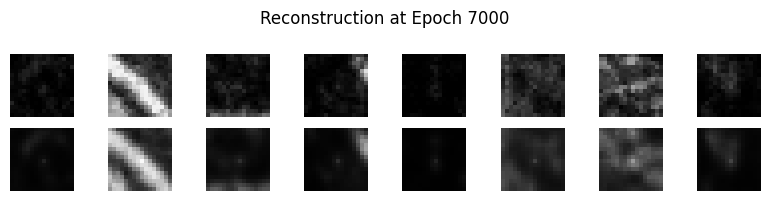

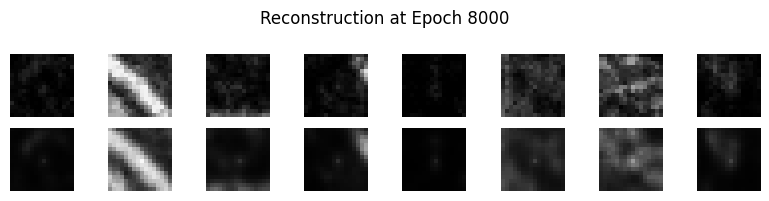

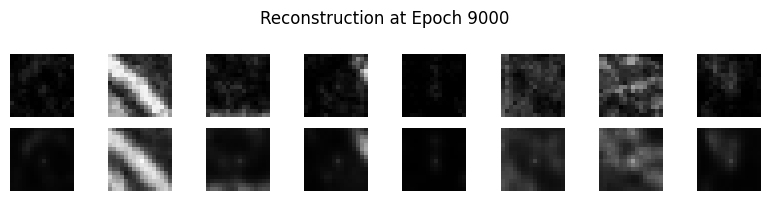

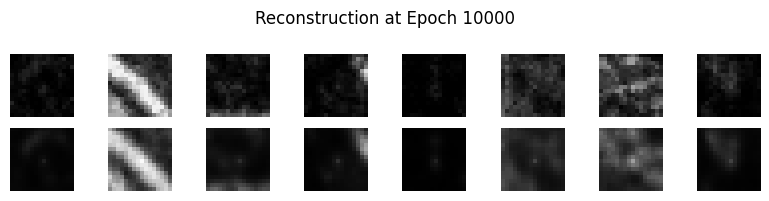

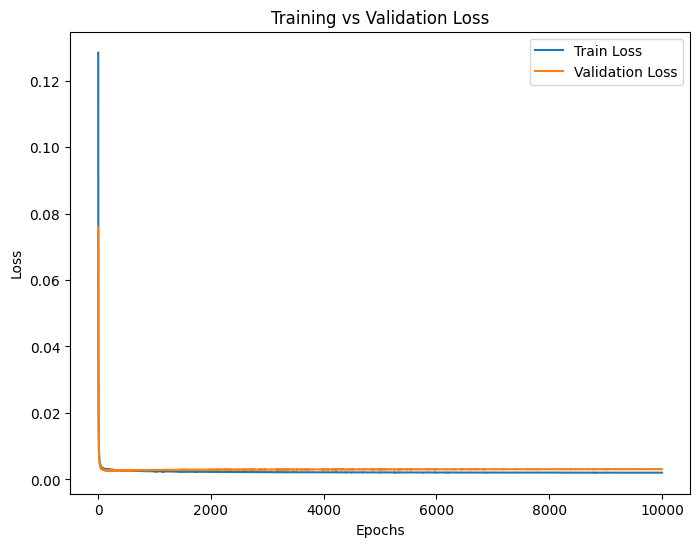

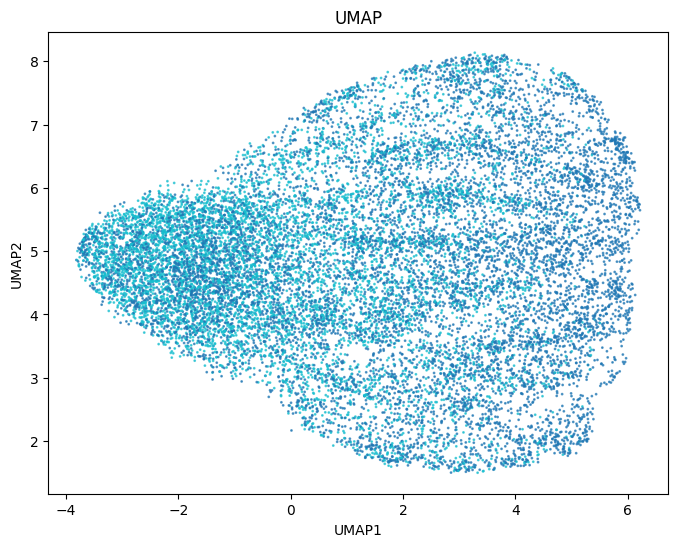

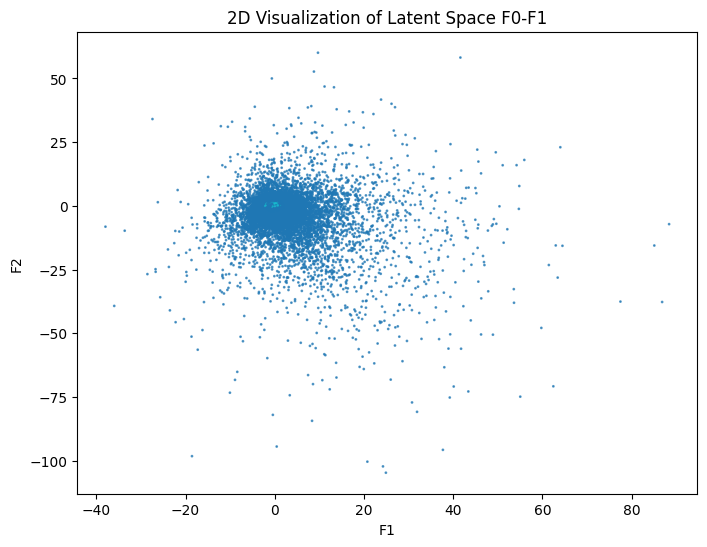

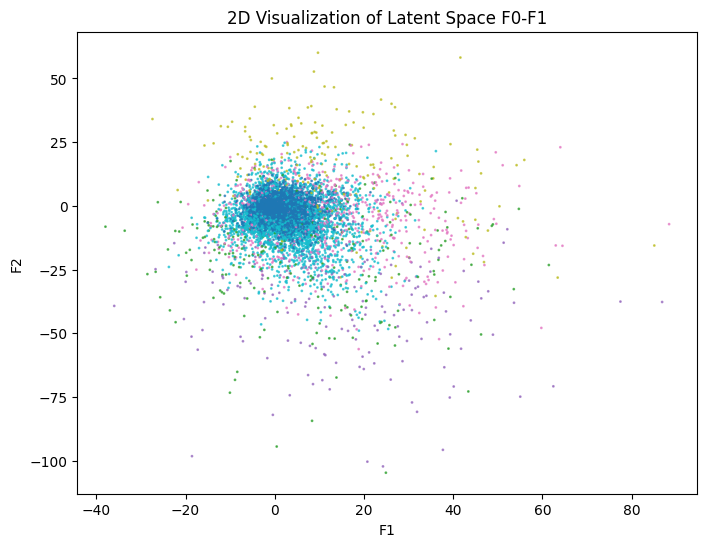

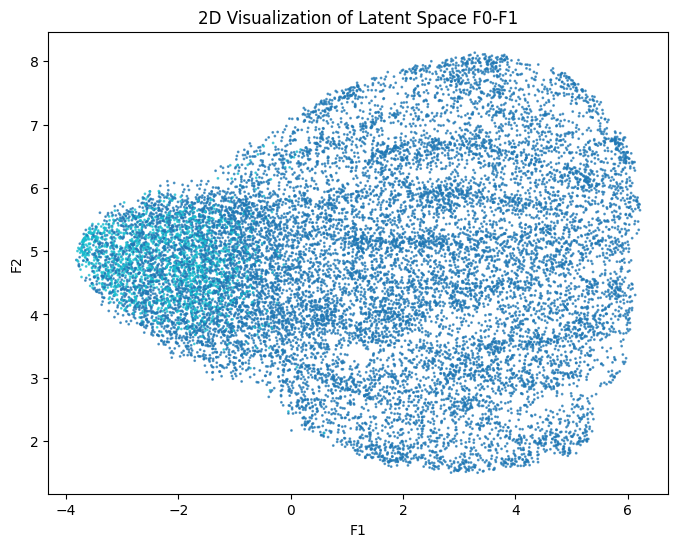

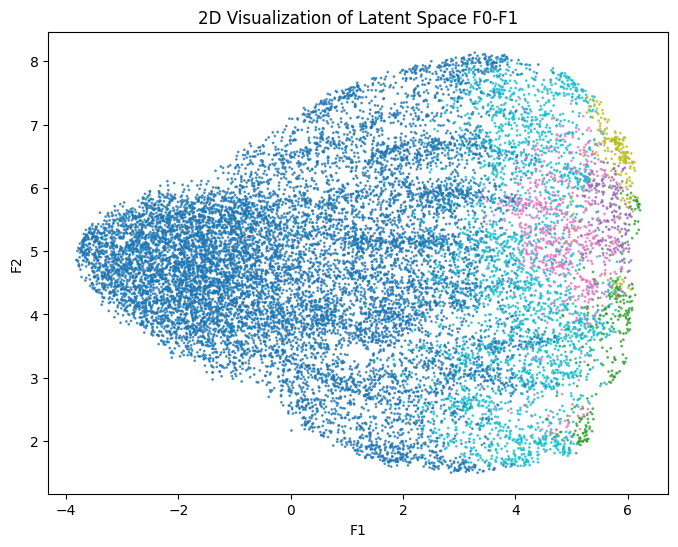

In [10]:
train_loss_across_latentdim = []
val_loss_across_latentdim = []

for  latent_dim in latent_dim_array:
        
    now = datetime.now()

    time_str = now.strftime("%Y%m%d_%H%M")

    result_dir = os.path.join('../results/', pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str)
    os.makedirs(result_dir, exist_ok=True)

    # Train AE
    ae = AE(latent_dim=latent_dim, input_ps=input_ps, BN_flag=BN_flag, dropout_flag=dropout_flag).to(device)

    ae, train_losses, val_losses = train_ae(ae, train_loader, val_loader, device, epochs=epochs, lr=lr, loss_norm_flag=loss_norm_flag, result_dir = result_dir)

    train_loss_across_latentdim.append(train_losses[-1])
    val_loss_across_latentdim.append(val_losses[-1])
    
    latents, images, group_id = dataloader_model_latents(ae, whole_data_loader, device)

    if isinstance(group_id, torch.Tensor):
        group_id = group_id.cpu().numpy()
    elif isinstance(group_id, list):
        group_id = torch.cat(group_id).cpu().numpy()

    latents_2d = UMAP_train(latents, result_dir)

    DBSCAN, DBSCAN_labels =  DBSCAN_cluster(latents, eps=eps, min_samples=min_samples, result_dir=result_dir)

    kmeans, kmeans_labels = kmeans_cluster(latents, num_clusters=kmeans_num_clusters, result_dir=result_dir)

    fig = umap_2Dplot(latents_2d, 0,1,group_id)
    fig.savefig(os.path.join(result_dir, 'umap_2d_grouplabels.png'))

    fig = cluster_2Dplot(latents, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_latent01_labels.png'))
    
    fig = cluster_2Dplot(latents, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_latent01_labels.png'))

    fig = cluster_2Dplot(latents_2d, 0,1,DBSCAN_labels)
    fig.savefig(os.path.join(result_dir, 'DBSCAN_umap2d_labels.png'))
    
    fig = cluster_2Dplot(latents_2d, 0,1,kmeans_labels)
    fig.savefig(os.path.join(result_dir, 'kmeans_umap2d_labels.png'))


In [11]:
joblib.dump(train_loss_across_latentdim, os.path.join('../results', 'train_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
joblib.dump(val_loss_across_latentdim, os.path.join('../results', 'val_loss_across_latentdim'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.pkl'))
    

['../results/val_loss_across_latentdimpax_front_localmax_correctloader_ch1_ps16_latdim_24_20251015_1504.pkl']

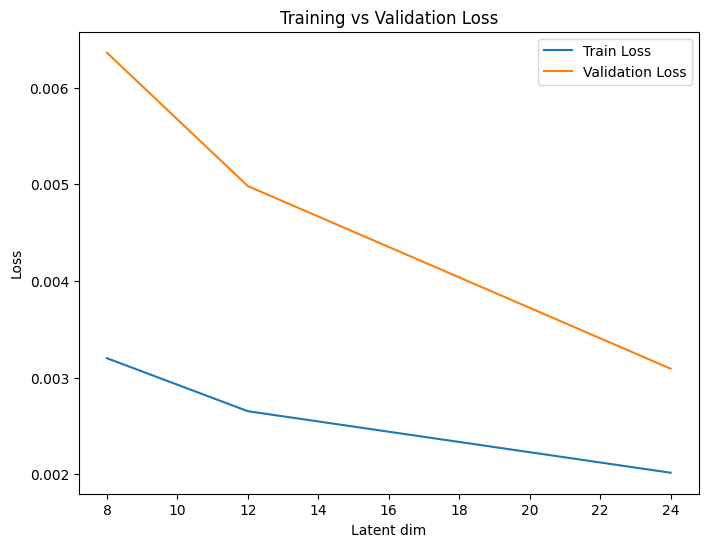

In [12]:
# Plot training and validation loss
fig = plt.figure(figsize=(8, 6))
plt.plot(latent_dim_array, train_loss_across_latentdim, label='Train Loss')
plt.plot(latent_dim_array, val_loss_across_latentdim, label='Validation Loss')
plt.xlabel('Latent dim')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
fig.savefig(os.path.join('../results', 'latent_dim_train_val_losses'+pro_str+'_ch' + str(main_ch) +'_'+ 'ps'+str(input_ps)+'_latdim_'+ str(latent_dim) +'_'+ time_str+'.png'))